# This is for 6 mL : 4 mL ratio at 37 deg C temperature

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
csv_path  = r"C:\Users\chand\Documents\GitHub\Thesis\M2_2.18mM_37deg_pressure_o2_release.csv"
time_col  = "Time (s)"                     # your column is actually hours
press_col = "DWT denoised pressure (kPa)"  # pressure in kPa
gas_col   = "O2 Released (µmol)"          # headspace O2 from csv
df = pd.read_csv(csv_path)
df.columns = [c.strip() for c in df.columns]

# Temperature according to time

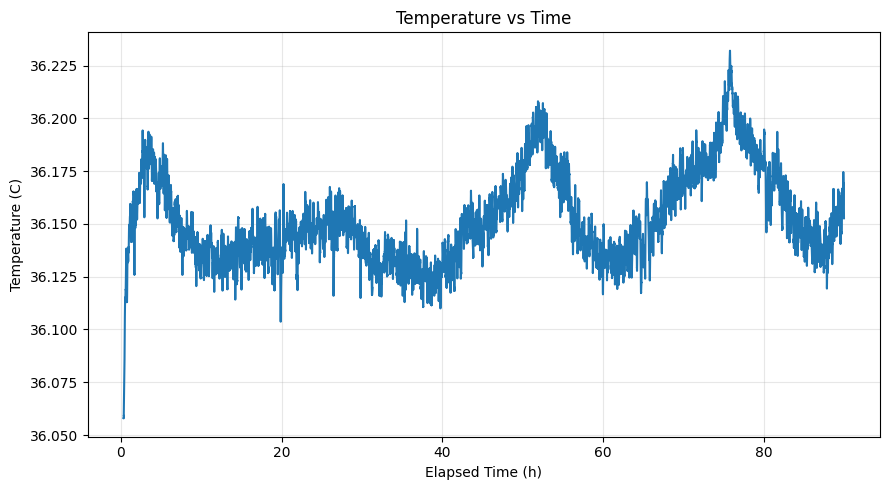

In [2]:
main_csv = r"C:\Users\chand\Documents\GitHub\Thesis\M2_2.18mM_37deg_pressure_o2_release.csv"
df_main = pd.read_csv(main_csv)
df_main.columns = [c.strip() for c in df_main.columns]
temperature_col = "calibrated temperature (C)"
time_col = "Time (s)"

t_h = pd.to_numeric(df_main[time_col], errors="coerce")
plt.figure(figsize=(9,5))
plt.plot(t_h, df_main[temperature_col], label="Temperature (C)")
plt.xlabel("Elapsed Time (h)")
plt.ylabel("Temperature (C)")
plt.title("Temperature vs Time")
plt.grid(True, alpha=0.3)
plt.tight_layout()
plt.show()

# Pressure in atm


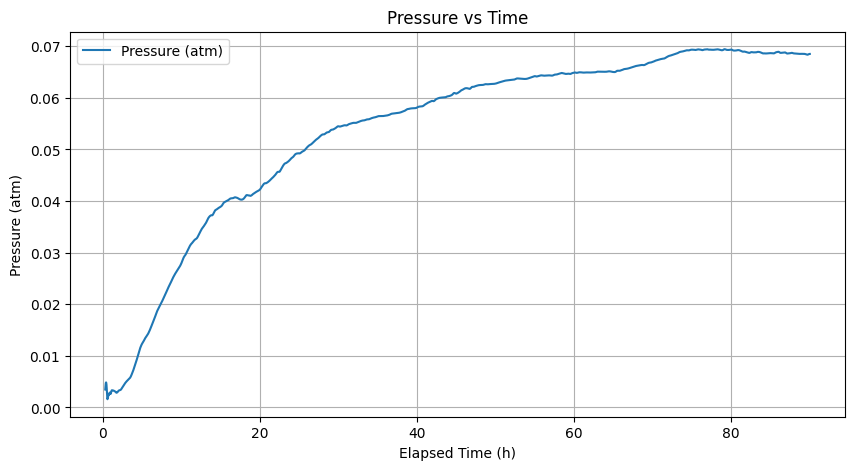

0.06943199624906128


In [3]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt



main_csv =  r"C:\Users\chand\Documents\GitHub\Thesis\M2_2.18mM_37deg_pressure_o2_release.csv"

df_main = pd.read_csv(main_csv)

df_main.columns = [c.strip() for c in df_main.columns]


pressure_col = df_main["DWT denoised pressure (kPa)"] / 101.325  # convert kPa to atm
time_col = df_main["Time (s)"] 

plt.figure(figsize=(10, 5))
plt.plot(time_col, pressure_col, label="Pressure (atm)")
plt.xlabel("Elapsed Time (h)")
plt.ylabel("Pressure (atm)")
plt.title("Pressure vs Time")
plt.legend()
plt.grid()
plt.show()

print(max(pressure_col))

# Headspace o2 detected by sensor

The headspace o2 column in the csv is not accurate, the recalculated value is stored in O2_37released_multi_volumes.csv

In [10]:
import pandas as pd

# ---------- Constants ----------
R = 0.082057  # L⋅atm/(mol⋅K)
V_headspace_volumes = [0.0039, 0.004, 0.0041]  # L (3.9, 4.0, 4.1 mL headspace)

input_csv =  r"C:\Users\chand\Documents\GitHub\Thesis\M2_2.18mM_37deg_pressure_o2_release.csv"
kh_csv     = r"C:\Users\chand\Documents\GitHub\Thesis\M2_2.18mM_37deg_pressure_o2_release37deg_DeltaH_from_T.csv"
df = pd.read_csv(input_csv)
df.columns = [c.strip() for c in df.columns]
df_kh = pd.read_csv(kh_csv)
df_kh.columns = [c.strip() for c in df_kh.columns]

# Extract data
pressure_kpa = pd.to_numeric(df["DWT denoised pressure (kPa)"], errors="coerce")
temp = pd.to_numeric(df_kh["T_K_from_rounded"], errors="coerce")
pressure_atm = pressure_kpa / 101.325

# Create output dataframe starting with original data
df_output = df.copy()

# Calculate O2 for each headspace volume
for V_headspace in V_headspace_volumes:
    n_o2_mol = (pressure_atm * V_headspace) / (R * temp)
    n_o2_umol = n_o2_mol * 1e6
    
    # Create column name with volume in mL
    column_name = f"O2 Released (µmol) - Vg={V_headspace*1000:.1f}mL"
    df_output[column_name] = n_o2_umol

# Save to CSV
output_csv = "O2_37released_multi_volumes.csv"
df_output.to_csv(output_csv, index=False)

print(f"Saved to: {output_csv}")

Saved to: O2_37released_multi_volumes.csv


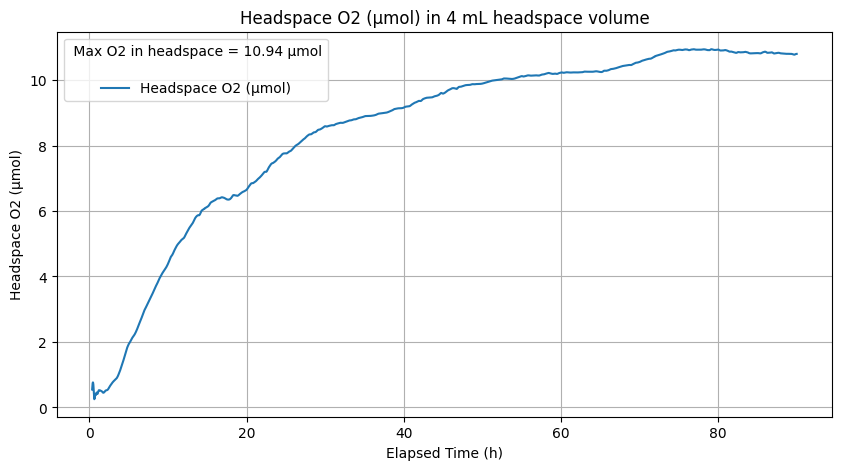

10.941489028892631


In [12]:
#code for headpace o2 in 4ml

import pandas as pd
import numpy as np
import matplotlib.pyplot as plt



main_csv = r"O2_37released_multi_volumes.csv"   # has Time, Pressure, Temp
df_main = pd.read_csv(main_csv)
df_main.columns = [c.strip() for c in df_main.columns]


headspace_oxygen = df_main["O2 Released (µmol) - Vg=4.0mL"]
time_col = df_main["Time (s)"] 



plt.figure(figsize=(10, 5))
plt.plot(time_col, headspace_oxygen, label="Headspace O2 (µmol)")
plt.xlabel("Elapsed Time (h)")
plt.ylabel("Headspace O2 (µmol)")
plt.title("Headspace O2 (µmol) in 4 mL headspace volume")


# Add small legend box with approach descriptions
legend_text = (
    " Max O2 in headspace = {:.2f} µmol\n"
).format(max(headspace_oxygen))
plt.legend(title=legend_text)
plt.grid()
plt.show()

print(max(headspace_oxygen))

# Dissolved O2

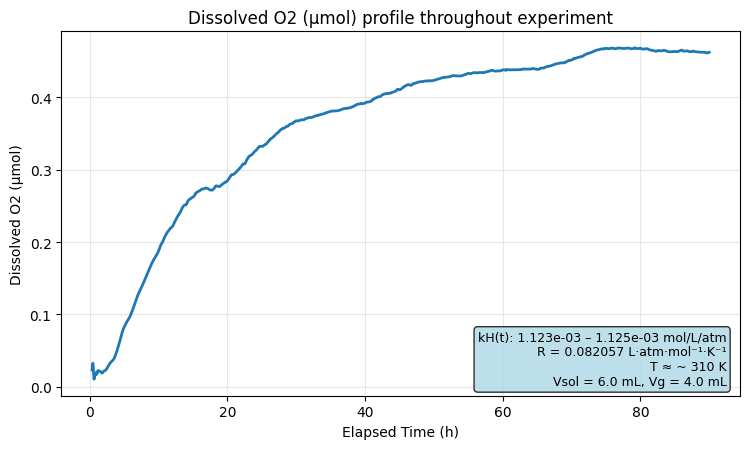

0.4681648939062673
0.4621483342808676


In [16]:
#code for dissolved o2


import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

# ---------- inputs ----------
main_csv   =  r"C:\Users\chand\Documents\GitHub\Thesis\M2_2.18mM_37deg_pressure_o2_release.csv" 
kh_csv     = r"C:\Users\chand\Documents\GitHub\Thesis\henrys_constants_37deg.csv"
time_col   = "Time (s)"  
press_col  = "DWT denoised pressure (kPa)"                                  

# ---------- constants ----------
R = 0.082057            # L·atm·mol^-1·K^-1

Vsol = 0.006            # L
Vg   = 0.004            # L

# ---------- load ----------
df = pd.read_csv(main_csv)
df.columns = [c.strip() for c in df.columns]
df_kh = pd.read_csv(kh_csv)
df_kh.columns = [c.strip() for c in df_kh.columns]



time_h = pd.to_numeric(df[time_col], errors="coerce")
p_kpa  = pd.to_numeric(df[press_col], errors="coerce")
kH_time = df_kh["kH_mol_per_L_atm"]
p_atm = p_kpa / 101.325    # convert kPa to atm


n_aq_umol = (kH_time * Vsol * p_atm) * 1e6    # dissolved O2 from Henry (µmol)

# ---------- assemble output ----------
df_out = pd.DataFrame({
    "Elapsed Time (h)": time_h,
    "p_kpa (kPa)": p_kpa,
    "p_atm (atm)": p_atm,
    "kH (mol/L/atm)": kH_time,
    "n_aq (µmol)": n_aq_umol
})

# ---------- plot ----------
plt.figure(figsize=(7.6, 4.6))
plt.plot(df_out["Elapsed Time (h)"], df_out["n_aq (µmol)"], linewidth=2)
plt.ylabel("Dissolved O2 (µmol)")
plt.xlabel("Elapsed Time (h)")
plt.title("Dissolved O2 (µmol) profile throughout experiment")

kH_min, kH_max = float(np.nanmin(kH_time)), float(np.nanmax(kH_time))
info_text = (
    f"kH(t): {kH_min:.3e} – {kH_max:.3e} mol/L/atm\n"
    f"R = {R} L·atm·mol⁻¹·K⁻¹\n"
    f"T ≈ ~ 310 K\n"
    f"Vsol = {Vsol*1000:.1f} mL, Vg = {Vg*1000:.1f} mL"
)
plt.text(0.98, 0.02, info_text,
         transform=plt.gca().transAxes,
         va="bottom", ha="right", fontsize=9,
         bbox=dict(boxstyle="round", facecolor="lightblue", alpha=0.8))

plt.grid(True, alpha=0.3)
plt.tight_layout()
plt.show()

print(max(n_aq_umol))
print(n_aq_umol.iloc[-1])

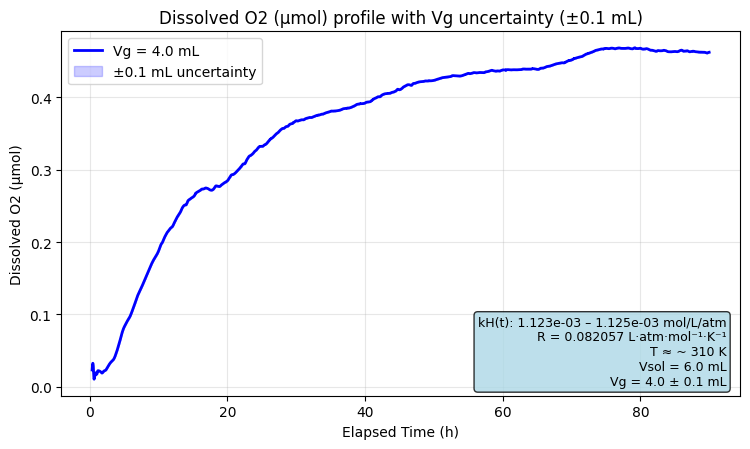

0.4681648939062673


In [17]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt


main_csv   =  r"C:\Users\chand\Documents\GitHub\Thesis\M2_2.18mM_37deg_pressure_o2_release.csv" 
kh_csv     = r"C:\Users\chand\Documents\GitHub\Thesis\henrys_constants_37deg.csv"
time_col   = "Time (s)"  
press_col  = "DWT denoised pressure (kPa)"                                  


R = 0.082057            # L·atm·mol^-1·K^-1
Vsol = 0.006            # L
Vg_center = 0.0040      # L (4.0 mL)
Vg_low    = 0.0039      # L (3.9 mL)
Vg_high   = 0.0041      # L (4.1 mL)


df = pd.read_csv(main_csv)
df.columns = [c.strip() for c in df.columns]
df_kh = pd.read_csv(kh_csv)
df_kh.columns = [c.strip() for c in df_kh.columns]

time_h = pd.to_numeric(df[time_col], errors="coerce") 
p_kpa  = pd.to_numeric(df[press_col], errors="coerce")
kH_time = df_kh["kH_mol_per_L_atm"]
temp = pd.to_numeric(df_kh["Temperature_K"], errors="coerce")
p_atm = p_kpa / 101.325    # convert kPa to atm


n_aq_center = (kH_time * Vsol * p_atm) * 1e6
n_aq_low    = (kH_time * Vsol * p_atm) * 1e6  # same formula (Vg doesn't affect n_aq directly!)
n_aq_high   = (kH_time * Vsol * p_atm) * 1e6

plt.figure(figsize=(7.6, 4.6))
plt.plot(time_h, n_aq_center, linewidth=2, color="blue", label="Vg = 4.0 mL")
plt.fill_between(time_h, n_aq_low, n_aq_high, color="blue", alpha=0.2, label="±0.1 mL uncertainty")

plt.ylabel("Dissolved O2 (µmol)")
plt.xlabel("Elapsed Time (h)")
plt.title("Dissolved O2 (µmol) profile with Vg uncertainty (±0.1 mL)")
plt.legend()

kH_min, kH_max = float(np.nanmin(kH_time)), float(np.nanmax(kH_time))
info_text = (
    f"kH(t): {kH_min:.3e} – {kH_max:.3e} mol/L/atm\n"
    f"R = {R} L·atm·mol⁻¹·K⁻¹\n"
    f"T ≈ ~ 310 K\n"
    f"Vsol = {Vsol*1000:.1f} mL\n"
    f"Vg = 4.0 ± 0.1 mL"
)
plt.text(0.98, 0.02, info_text,
         transform=plt.gca().transAxes,
         va="bottom", ha="right", fontsize=9,
         bbox=dict(boxstyle="round", facecolor="lightblue", alpha=0.8))

plt.grid(True, alpha=0.3)
plt.tight_layout()
plt.show()

print(max(n_aq_center))

# Comparison between headspace oxygen and dissolved oxygen

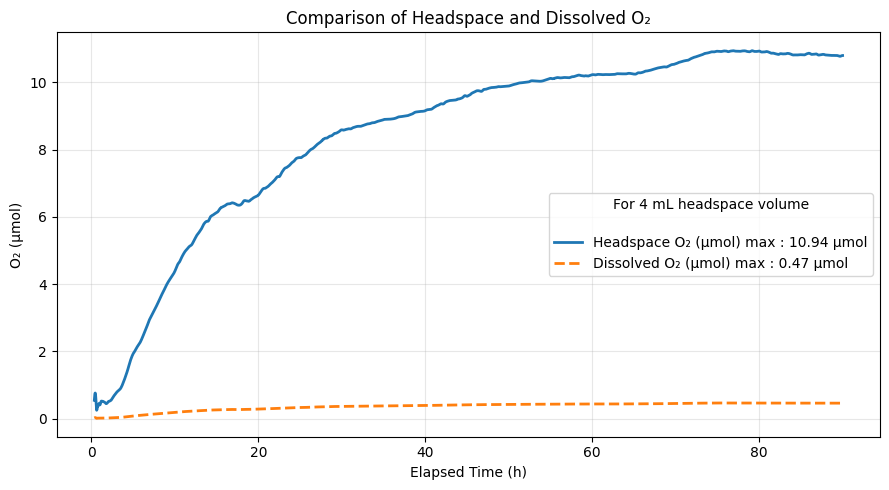

Max Headspace O2: 10.94 µmol
Max Dissolved O2: 0.47 µmol


In [19]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

# ---------- inputs ----------
headspace_csv = r"O2_37released_multi_volumes.csv"   # has Time, O2 Released columns
dissolved_main_csv =  r"C:\Users\chand\Documents\GitHub\Thesis\M2_2.18mM_37deg_pressure_o2_release.csv"      
kh_csv =r"C:\Users\chand\Documents\GitHub\Thesis\henrys_constants_37deg.csv"

time_col   = "Time (s)"  
press_col  = "DWT denoised pressure (kPa)"                                  

# ---------- constants ----------
R = 0.082057   # L·atm·mol^-1·K^-1
Vsol = 0.006   # L
Vg   = 0.004   # L

# ---------- load headspace ----------
df_hs = pd.read_csv(headspace_csv)
df_hs.columns = [c.strip() for c in df_hs.columns]

time_hs = pd.to_numeric(df_hs["Time (s)"], errors="coerce")
headspace_oxygen = pd.to_numeric(df_hs["O2 Released (µmol) - Vg=4.0mL"], errors="coerce")

# ---------- load dissolved ----------
df_main = pd.read_csv(dissolved_main_csv)
df_main.columns = [c.strip() for c in df_main.columns]
df_kh = pd.read_csv(kh_csv)
df_kh.columns = [c.strip() for c in df_kh.columns]

time_ds = pd.to_numeric(df_main[time_col], errors="coerce")
p_kpa = pd.to_numeric(df_main[press_col], errors="coerce")
kH_time = pd.to_numeric(df_kh["kH_mol_per_L_atm"], errors="coerce")
p_atm = p_kpa / 101.325    # convert kPa to atm

n_aq_umol = (kH_time * Vsol * p_atm) * 1e6    # dissolved O2 from Henry (µmol)

# ---------- plot both ----------
plt.figure(figsize=(9, 5))
plt.plot(time_hs, headspace_oxygen, label="Headspace O₂ (µmol) max : {:.2f} µmol".format(headspace_oxygen.max()), linewidth=2)
plt.plot(time_ds, n_aq_umol, label="Dissolved O₂ (µmol) max : {:.2f} µmol".format(n_aq_umol.max()), linewidth=2, linestyle="--")

legend_text = (
    "For 4 mL headspace volume\n"
)
plt.legend(title=legend_text)
# labels and formatting
plt.xlabel("Elapsed Time (h)")
plt.ylabel("O₂ (µmol)")
plt.title("Comparison of Headspace and Dissolved O₂")

plt.grid(True, alpha=0.3)
plt.tight_layout()
plt.show()

print(f"Max Headspace O2: {headspace_oxygen.max():.2f} µmol")
print(f"Max Dissolved O2: {n_aq_umol.max():.2f} µmol")


# Comparing total oxygen released with dissolved oxygen and headspace oxygen :

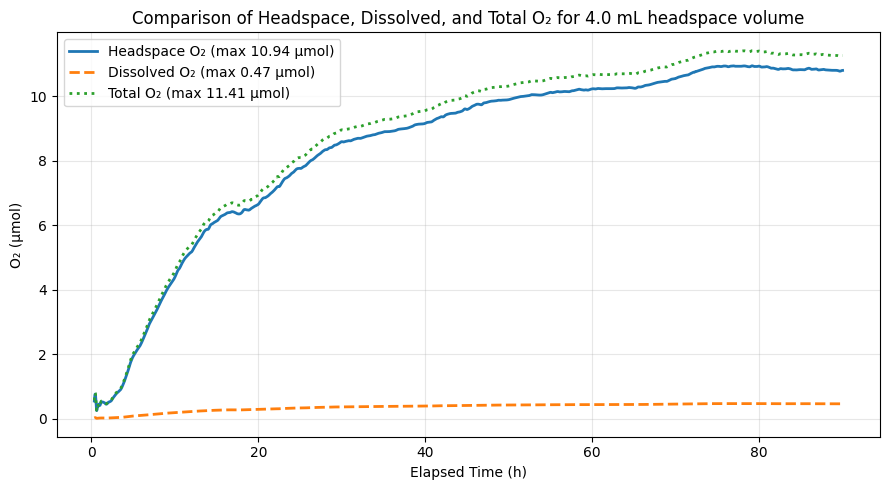

Final Headspace O₂: 10.80 µmol
Final Dissolved O₂: 0.46 µmol
Final Total O₂: 11.26 µmol


In [22]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt




headspace_csv = r"O2_37released_multi_volumes.csv"   # has Time, O2 Released columns
dissolved_main_csv =  r"C:\Users\chand\Documents\GitHub\Thesis\M2_2.18mM_37deg_pressure_o2_release.csv"      
kh_csv =r"C:\Users\chand\Documents\GitHub\Thesis\henrys_constants_37deg.csv"

time_col   = "Time (s)"  
press_col  = "DWT denoised pressure (kPa)"                                  

# ---------- constants ----------
R = 0.082057   # L·atm·mol^-1·K^-1
Vsol = 0.006   # L
Vg   = 0.004   # L


# ---------- load headspace ----------
df_hs = pd.read_csv(headspace_csv)
df_hs.columns = [c.strip() for c in df_hs.columns]

time_hs = pd.to_numeric(df_hs["Time (s)"], errors="coerce")
headspace_oxygen = pd.to_numeric(df_hs["O2 Released (µmol) - Vg=4.0mL"], errors="coerce")

# ---------- load dissolved ----------
df_main = pd.read_csv(dissolved_main_csv)
df_main.columns = [c.strip() for c in df_main.columns]
df_kh = pd.read_csv(kh_csv)
df_kh.columns = [c.strip() for c in df_kh.columns]

time_ds = pd.to_numeric(df_main[time_col], errors="coerce")
p_kpa = pd.to_numeric(df_main[press_col], errors="coerce")
kH_time = pd.to_numeric(df_kh["kH_mol_per_L_atm"], errors="coerce")
p_atm = p_kpa / 101.325    # convert kPa to atm

n_aq_umol = (kH_time * Vsol * p_atm) * 1e6    # dissolved O2 from Henry (µmol)

# ---------- align time if necessary ----------
n = min(len(time_hs), len(headspace_oxygen), len(time_ds), len(n_aq_umol))
time = time_hs.iloc[:n].reset_index(drop=True)
headspace_oxygen = headspace_oxygen.iloc[:n].reset_index(drop=True)
n_aq_umol = n_aq_umol.iloc[:n].reset_index(drop=True)

# ---------- total O2 ----------
n_total_umol = headspace_oxygen + n_aq_umol

plt.figure(figsize=(9, 5))
plt.plot(time, headspace_oxygen, label=f"Headspace O₂ (max {headspace_oxygen.max():.2f} µmol)", linewidth=2)
plt.plot(time, n_aq_umol, label=f"Dissolved O₂ (max {n_aq_umol.max():.2f} µmol)", linewidth=2, linestyle="--")
plt.plot(time, n_total_umol, label=f"Total O₂ (max {n_total_umol.max():.2f} µmol)", linewidth=2, linestyle=":")

plt.legend(loc="upper left")


plt.xlabel("Elapsed Time (h)")
plt.ylabel("O₂ (µmol)")
plt.title("Comparison of Headspace, Dissolved, and Total O₂ for 4.0 mL headspace volume")
plt.grid(True, alpha=0.3)
plt.tight_layout()
plt.show()




print(f"Final Headspace O₂: {headspace_oxygen.iloc[-1]:.2f} µmol")
print(f"Final Dissolved O₂: {n_aq_umol.iloc[-1]:.2f} µmol")
print(f"Final Total O₂: {n_total_umol.iloc[-1]:.2f} µmol")


# Total oxygen released

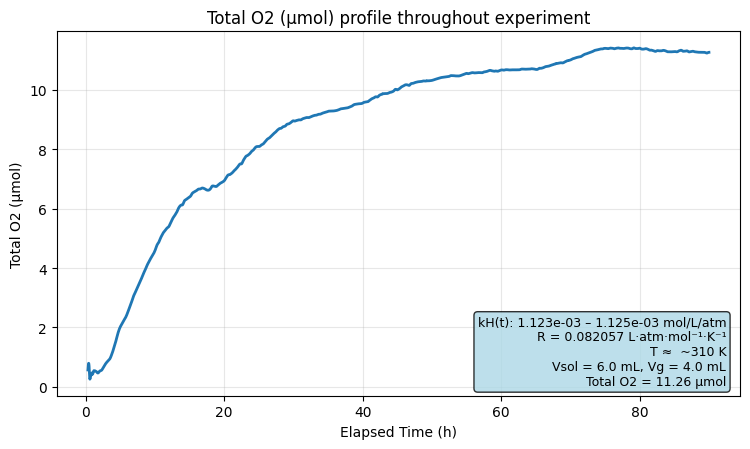

11.409653922798897
11.260913818980512


In [29]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

# ---------- inputs ----------
main_csv   = r"O2_37released_multi_volumes.csv"      
kh_csv =r"C:\Users\chand\Documents\GitHub\Thesis\henrys_constants_37deg.csv"     

# ---------- constants ----------
R = 0.082057            # L·atm·mol^-1·K^-1
Vsol = 0.006            # L
Vg   = 0.004         # L

# ---------- load ----------
df = pd.read_csv(main_csv)
df.columns = [c.strip() for c in df.columns]
df_kh = pd.read_csv(kh_csv)
df_kh.columns = [c.strip() for c in df_kh.columns]



time_h = pd.to_numeric(df["Time (s)"], errors="coerce")
p_kpa  = pd.to_numeric(df["DWT denoised pressure (kPa)"], errors="coerce")
kH_time = pd.to_numeric(df_kh["kH_mol_per_L_atm"], errors="coerce")
temp = pd.to_numeric(df_kh["Temperature_K"], errors="coerce")



p_atm = p_kpa / 101.325    # convert kPa to atm




def calculate_n_total (p_kpa: pd.Series, Vg: float, Vsol: float, R: float, T: float, KH: float) -> pd.Series:
    ntot = p_atm * ( (Vg / (R*T)) + (KH * Vsol)) 
    ntot_umol = ntot * 1e6  # Convert to µmol
    return ntot_umol

ntot_umol = calculate_n_total(p_atm, Vg, Vsol, R, temp, kH_time)



# ---------- assemble output ----------
df_out = pd.DataFrame({
    "Elapsed Time (h)": time_h,
    "p_atm (atm)": p_atm,
    "kH (mol/L/atm)": kH_time,
    "n_total(µmol)": ntot_umol
})

# ---------- plot ----------
plt.figure(figsize=(7.6, 4.6))
plt.plot(df_out["Elapsed Time (h)"], df_out["n_total(µmol)"], linewidth=2)
plt.ylabel("Total O2 (µmol)")
plt.xlabel("Elapsed Time (h)")
plt.title("Total O2 (µmol) profile throughout experiment")

kH_min, kH_max = float(np.nanmin(kH_time)), float(np.nanmax(kH_time))
info_text = (
    f"kH(t): {kH_min:.3e} – {kH_max:.3e} mol/L/atm\n"
    f"R = {R} L·atm·mol⁻¹·K⁻¹\n"
    f"T ≈  ~310 K\n"
    f"Vsol = {Vsol*1000:.1f} mL, Vg = {Vg*1000:.1f} mL\n"
    f"Total O2 = {ntot_umol.iloc[-1]:.2f} µmol"
)
plt.text(0.98, 0.02, info_text,
         transform=plt.gca().transAxes,
         va="bottom", ha="right", fontsize=9,
         bbox=dict(boxstyle="round", facecolor="lightblue", alpha=0.8))

plt.grid(True, alpha=0.3)
plt.tight_layout()
plt.show()


print(max(ntot_umol))
print(ntot_umol.iloc[-1])

# With uncertainity

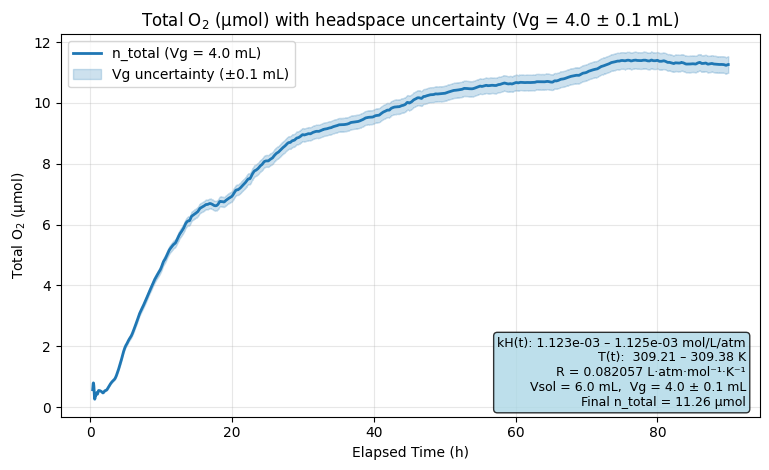

Max n_total (center): 11.409653922798897
Final n_total (center): 11.260913818980512


In [32]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

# ---------- inputs ----------


main_csv   = r"O2_37released_multi_volumes.csv"      
kh_csv =r"C:\Users\chand\Documents\GitHub\Thesis\henrys_constants_37deg.csv"    
time_col   = "Time (s)"
press_col  = "DWT denoised pressure (kPa)"

# ---------- constants ----------
R    = 0.082057      # L·atm·mol^-1·K^-1
Vsol = 0.006         # L
Vg_center = 0.0040   # L (4.0 mL)
Vg_low    = 0.0039   # L (3.9 mL)
Vg_high   = 0.0041   # L (4.1 mL)

# ---------- load ----------
df    = pd.read_csv(main_csv)
df_kh = pd.read_csv(kh_csv)
df.columns    = [c.strip() for c in df.columns]
df_kh.columns = [c.strip() for c in df_kh.columns]

# parse & align
time_h  = pd.to_numeric(df[time_col], errors="coerce") 
p_kpa   = pd.to_numeric(df[press_col], errors="coerce")
p_atm   = p_kpa / 101.325
kH_time = pd.to_numeric(df_kh["kH_mol_per_L_atm"], errors="coerce")
T_time  = pd.to_numeric(df_kh["Temperature_K"],    errors="coerce")

n = min(len(time_h), len(p_atm), len(kH_time), len(T_time))
time_h, p_atm, kH_time, T_time = [s.iloc[:n].reset_index(drop=True) for s in (time_h, p_atm, kH_time, T_time)]

# ---------- n_total for different Vg (µmol) ----------
def n_total_umol(p_atm, Vg, Vsol, R, T, kH):
    A = (Vg / (R * T)) + (kH * Vsol)         # mol/atm
    return (p_atm * A) * 1e6                 # µmol

ntot_center = n_total_umol(p_atm, Vg_center, Vsol, R, T_time, kH_time)
ntot_low    = n_total_umol(p_atm, Vg_low,    Vsol, R, T_time, kH_time)
ntot_high   = n_total_umol(p_atm, Vg_high,   Vsol, R, T_time, kH_time)

# ---------- plot with uncertainty band ----------
plt.figure(figsize=(7.8, 4.8))
plt.plot(time_h, ntot_center, color="C0", lw=2, label="n_total (Vg = 4.0 mL)")
plt.fill_between(time_h, ntot_low, ntot_high, color="C0", alpha=0.22, label="Vg uncertainty (±0.1 mL)")

plt.xlabel("Elapsed Time (h)")
plt.ylabel("Total O$_2$ (µmol)")
plt.title("Total O$_2$ (µmol) with headspace uncertainty (Vg = 4.0 ± 0.1 mL)")
plt.grid(True, alpha=0.3)
plt.legend(loc="upper left")

# info box
kH_min, kH_max = float(np.nanmin(kH_time)), float(np.nanmax(kH_time))
T_min,  T_max  = float(np.nanmin(T_time)),  float(np.nanmax(T_time))
info_text = (
    f"kH(t): {kH_min:.3e} – {kH_max:.3e} mol/L/atm\n"
    f"T(t):  {T_min:.2f} – {T_max:.2f} K\n"
    f"R = {R} L·atm·mol⁻¹·K⁻¹\n"
    f"Vsol = {Vsol*1000:.1f} mL,  Vg = 4.0 ± 0.1 mL\n"
    f"Final n_total = {ntot_center.iloc[-1]:.2f} µmol"
)
plt.text(0.98, 0.02, info_text,
         transform=plt.gca().transAxes,
         ha="right", va="bottom", fontsize=9,
         bbox=dict(boxstyle="round", facecolor="lightblue", alpha=0.8))

plt.tight_layout()
plt.show()

print("Max n_total (center):", float(np.nanmax(ntot_center)))
print("Final n_total (center):", float(ntot_center.iloc[-1]))


# Comparison of total oxygen released (dissolved + headspace) plot with theoretical max 13.08

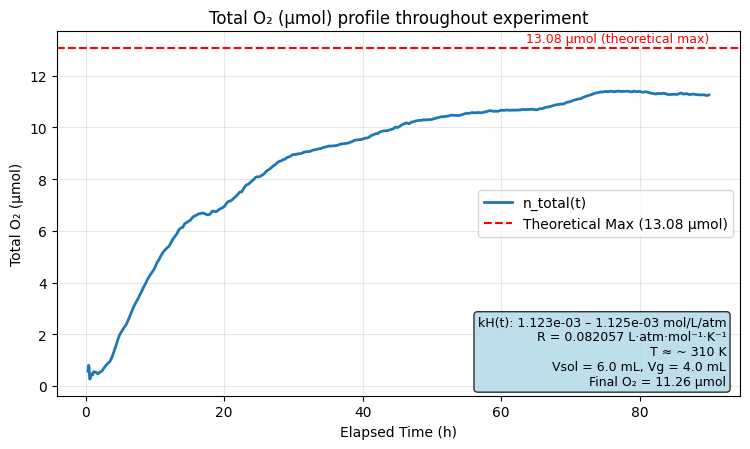

In [34]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

# ---------- inputs ----------
main_csv   = r"O2_37released_multi_volumes.csv"      
kh_csv =r"C:\Users\chand\Documents\GitHub\Thesis\henrys_constants_37deg.csv"    
time_col   = "Time (s)"  
press_col  = "DWT denoised pressure (kPa)"                                  

# ---------- constants ----------
R = 0.082057            # L·atm·mol^-1·K^-1
Vsol = 0.006            # L
Vg   = 0.004            # L
n_theory = 13.08        # µmol (theoretical maximum O2)

# ---------- load ----------
df = pd.read_csv(main_csv)
df.columns = [c.strip() for c in df.columns]
df_kh = pd.read_csv(kh_csv)
df_kh.columns = [c.strip() for c in df_kh.columns]
T_time  = pd.to_numeric(df_kh["Temperature_K"],    errors="coerce")
time_h = pd.to_numeric(df[time_col], errors="coerce")
p_kpa  = pd.to_numeric(df[press_col], errors="coerce")
kH_time = df_kh["kH_mol_per_L_atm"]
p_atm = p_kpa / 101.325    # convert kPa to atm

# ---------- calculate n_total ----------
def calculate_n_total(p_atm, Vg, Vsol, R, T, KH):
    ntot = p_atm * ((Vg / (R*T)) + (KH * Vsol))
    return ntot * 1e6  # µmol

ntot_umol = calculate_n_total(p_atm, Vg, Vsol, R, T_time, kH_time)

# ---------- assemble output ----------
df_out = pd.DataFrame({
    "Elapsed Time (h)": time_h,
    "p_atm (atm)": p_atm,
    "kH (mol/L/atm)": kH_time,
    "n_total (µmol)": ntot_umol
})

# ---------- plot ----------
plt.figure(figsize=(7.6, 4.6))
plt.plot(df_out["Elapsed Time (h)"], df_out["n_total (µmol)"], linewidth=2, label="n_total(t)")
plt.axhline(y=n_theory, color="red", linestyle="--", linewidth=1.5, label="Theoretical Max (13.08 µmol)")

# Put label near the top-right corner
plt.text(df_out["Elapsed Time (h)"].max(), n_theory+0.1,
         f"{n_theory} µmol (theoretical max)", color="red",
         ha="right", va="bottom", fontsize=9)

plt.ylabel("Total O₂ (µmol)")
plt.xlabel("Elapsed Time (h)")
plt.title("Total O₂ (µmol) profile throughout experiment")
plt.legend()

# Info box
kH_min, kH_max = float(np.nanmin(kH_time)), float(np.nanmax(kH_time))
info_text = (
    f"kH(t): {kH_min:.3e} – {kH_max:.3e} mol/L/atm\n"
    f"R = {R} L·atm·mol⁻¹·K⁻¹\n"
    f"T ≈ ~ 310 K\n"
    f"Vsol = {Vsol*1000:.1f} mL, Vg = {Vg*1000:.1f} mL\n"
    f"Final O₂ = {ntot_umol.iloc[-1]:.2f} µmol"
)
plt.text(0.98, 0.02, info_text,
         transform=plt.gca().transAxes,
         va="bottom", ha="right", fontsize=9,
         bbox=dict(boxstyle="round", facecolor="lightblue", alpha=0.8))

plt.grid(True, alpha=0.3)
plt.tight_layout()
plt.show()


# For 3.9 and 4.1 mL

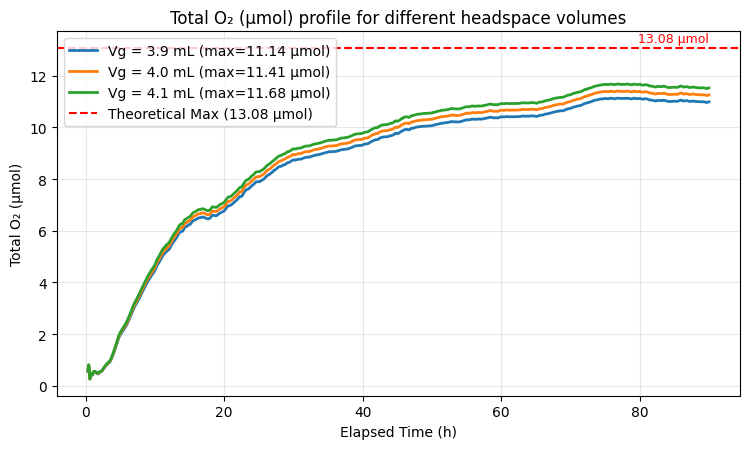

In [38]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

# ---------- inputs ----------
main_csv   = r"O2_37released_multi_volumes.csv"      
kh_csv =r"C:\Users\chand\Documents\GitHub\Thesis\henrys_constants_37deg.csv"    
time_col   = "Time (s)"  
press_col  = "DWT denoised pressure (kPa)"                                  

# ---------- constants ----------
R = 0.082057            # L·atm·mol^-1·K^-1
Vsol = 0.006            # L
Vg_values = [0.0039, 0.0040, 0.0041]  # L (3.9, 4.0, 4.1 mL)
n_theory = 13.08        # µmol (theoretical maximum O2)

# ---------- load ----------
df = pd.read_csv(main_csv)
df.columns = [c.strip() for c in df.columns]
df_kh = pd.read_csv(kh_csv)
df_kh.columns = [c.strip() for c in df_kh.columns]

T_time  = pd.to_numeric(df_kh["Temperature_K"], errors="coerce")
time_h  = pd.to_numeric(df[time_col], errors="coerce")
p_kpa   = pd.to_numeric(df[press_col], errors="coerce")
kH_time = df_kh["kH_mol_per_L_atm"]
p_atm   = p_kpa / 101.325    # convert kPa to atm

# ---------- calculate n_total ----------
def calculate_n_total(p_atm, Vg, Vsol, R, T, KH):
    ntot = p_atm * ((Vg / (R*T)) + (KH * Vsol))
    return ntot * 1e6  # µmol

# ---------- plot ----------
plt.figure(figsize=(7.6, 4.6))

# Plot for each Vg value
for Vg in Vg_values:
    ntot_umol = calculate_n_total(p_atm, Vg, Vsol, R, T_time, kH_time)
    plt.plot(time_h, ntot_umol, linewidth=2, label=f"Vg = {Vg*1000:.1f} mL (max={ntot_umol.max():.2f} µmol)")

# Add theoretical max line
plt.axhline(y=n_theory, color="red", linestyle="--", linewidth=1.5, label="Theoretical Max (13.08 µmol)")
plt.text(time_h.max(), n_theory+0.1,
         f"{n_theory} µmol", color="red",
         ha="right", va="bottom", fontsize=9)

# Labels and title
plt.ylabel("Total O₂ (µmol)")
plt.xlabel("Elapsed Time (h)")
plt.title("Total O₂ (µmol) profile for different headspace volumes")
plt.legend(loc="upper left")
plt.grid(True, alpha=0.3)
plt.tight_layout()
plt.show()


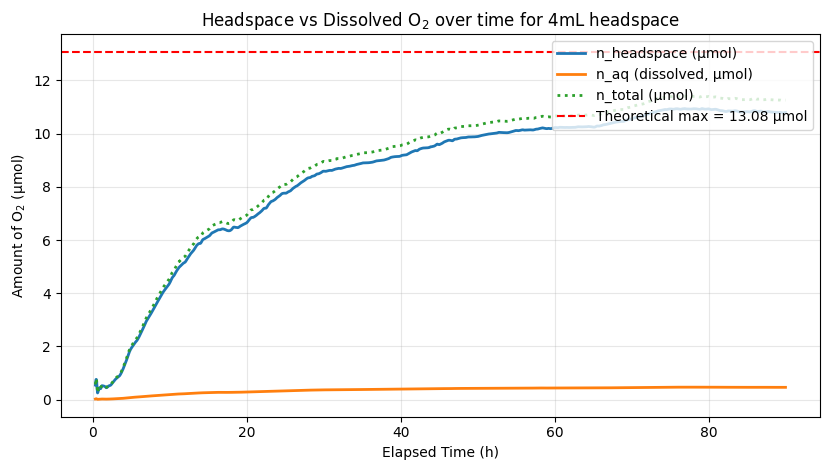

In [39]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

# ---------- inputs ----------
main_csv   = r"O2_37released_multi_volumes.csv"
kh_csv =r"C:\Users\chand\Documents\GitHub\Thesis\henrys_constants_37deg.csv"
time_col   = "Time (s)"  
press_col  = "DWT denoised pressure (kPa)"                                  

# ---------- constants ----------
R = 0.082057            # L·atm·mol^-1·K^-1
Vsol = 0.006            # L
Vg   = 0.004            # L
n_theory = 13.08        # µmol (theoretical maximum O2)

# ---------- load ----------
df = pd.read_csv(main_csv)
df.columns = [c.strip() for c in df.columns]
df_kh = pd.read_csv(kh_csv)
df_kh.columns = [c.strip() for c in df_kh.columns]


T_time  = pd.to_numeric(df_kh["Temperature_K"],    errors="coerce")
time_h = pd.to_numeric(df[time_col], errors="coerce")
p_kpa  = pd.to_numeric(df[press_col], errors="coerce")
kH_time = df_kh["kH_mol_per_L_atm"]
p_atm = p_kpa / 101.325    # convert kPa to atm

n_headspace = pd.to_numeric(df["O2 Released (µmol) - Vg=4.0mL"], errors="coerce")

# Dissolved O2 from Henry’s law (µmol)
n_aq_umol = (kH_time * Vsol * p_atm) * 1e6


n_total_umol = n_headspace + n_aq_umol

# ---- Plot both on one figure ----
plt.figure(figsize=(8.4, 4.8))
plt.plot(time_h, n_headspace, lw=2, label="n_headspace (µmol)")
plt.plot(time_h, n_aq_umol, lw=2, label="n_aq (dissolved, µmol)")
plt.plot(time_h, n_total_umol, lw=2, label="n_total (µmol)", linestyle=":")
plt.axhline(n_theory, ls="--", c="red", lw=1.5, label=f"Theoretical max = {n_theory} µmol")

plt.xlabel("Elapsed Time (h)")
plt.ylabel("Amount of O$_2$ (µmol)")
plt.title("Headspace vs Dissolved O$_2$ over time for 4mL headspace")
plt.grid(True, alpha=0.3)
plt.legend(loc="upper right")
plt.tight_layout()
plt.show()


df_out = pd.DataFrame({
    "Elapsed Time (h)": time_h,
    "p_atm (atm)": p_atm,
    "kH (mol/L/atm)": kH_time,
    "n_headspace (µmol)": n_headspace,
    "n_aq (µmol)": n_aq_umol,
    "n_total (µmol)": n_total_umol
})


# To save the ntotal umol into a csv file (for pressure predictor) ( just for 4 mL)

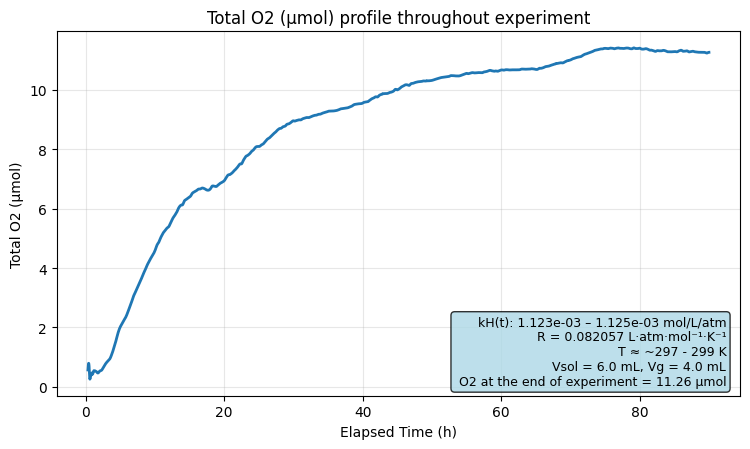

✅ Saved ntotal data to ntotal_output_37.csv


In [ ]:

import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

# ---------- inputs ----------
main_csv   = r"O2_37released_multi_volumes.csv"
kh_csv =r"C:\Users\chand\Documents\GitHub\Thesis\henrys_constants_37deg.csv"
# ---------- constants ----------
R = 0.082057            # L·atm·mol^-1·K^-1
Vsol = 0.006            # L
Vg   = 0.004            # L

# ---------- load ----------
df = pd.read_csv(main_csv)
df.columns = [c.strip() for c in df.columns]
df_kh = pd.read_csv(kh_csv)
df_kh.columns = [c.strip() for c in df_kh.columns]



time_h = pd.to_numeric(df["Time (s)"], errors="coerce")
p_kpa  = pd.to_numeric(df["DWT denoised pressure (kPa)"], errors="coerce")
kH_time = pd.to_numeric(df_kh["kH_mol_per_L_atm"], errors="coerce")
temp = pd.to_numeric(df_kh["Temperature_K"], errors="coerce")



p_atm = p_kpa / 101.325    # convert kPa to atm




def calculate_n_total (p_kpa: pd.Series, Vg: float, Vsol: float, R: float, T: float, KH: float) -> pd.Series:
    ntot = p_atm * ( (Vg / (R*T)) + (KH * Vsol)) 
    ntot_umol = ntot * 1e6  # Convert to µmol
    return ntot_umol

ntot_umol = calculate_n_total(p_atm, Vg, Vsol, R, temp, kH_time)



# ---------- assemble output ----------
df_out = pd.DataFrame({
    "Elapsed Time (h)": time_h,
    "p_atm (atm)": p_atm,
    "kH (mol/L/atm)": kH_time,
    "n_total(µmol)": ntot_umol
})

# ---------- plot ----------
plt.figure(figsize=(7.6, 4.6))
plt.plot(df_out["Elapsed Time (h)"], df_out["n_total(µmol)"], linewidth=2)
plt.ylabel("Total O2 (µmol)")
plt.xlabel("Elapsed Time (h)")
plt.title("Total O2 (µmol) profile throughout experiment")

kH_min, kH_max = float(np.nanmin(kH_time)), float(np.nanmax(kH_time))
info_text = (
    f"kH(t): {kH_min:.3e} – {kH_max:.3e} mol/L/atm\n"
    f"R = {R} L·atm·mol⁻¹·K⁻¹\n"
    f"T ≈ ~297 - 299 K\n"
    f"Vsol = {Vsol*1000:.1f} mL, Vg = {Vg*1000:.1f} mL\n"
    f" O2 at the end of experiment = {ntot_umol.iloc[-1]:.2f} µmol"
)
plt.text(0.98, 0.02, info_text,
         transform=plt.gca().transAxes,
         va="bottom", ha="right", fontsize=9,
         bbox=dict(boxstyle="round", facecolor="lightblue", alpha=0.8))

plt.grid(True, alpha=0.3)
plt.tight_layout()
plt.show()

# ---------- save to CSV ----------
output_csv = r"ntotal_output_37.csv"
df_out.to_csv(output_csv, index=False)
print(f" Saved ntotal data to {output_csv}")

# Comparing 37 and 25

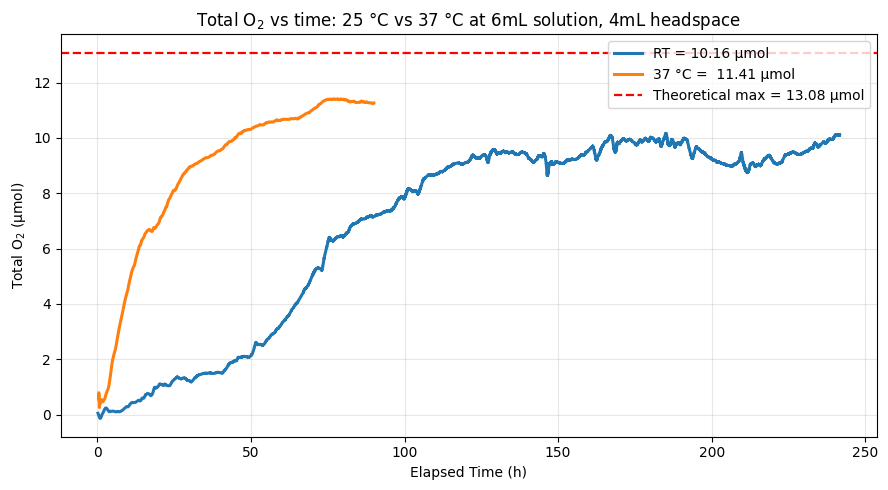

10.16, 11.41


In [8]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

# --- file paths ---
main_RT_csv = r"C:\Users\chand\Documents\GitHub\Thesis\M2_2.18mM_pressure_o2_release.csv"         # 25 °C
henry_RT_csv = r"C:\Users\chand\Documents\GitHub\Thesis\CSV files outputs -RT\Vant hoff modelling\henry's constants.csv"

main_37_csv = r"C:\Users\chand\Documents\GitHub\Thesis\M2_2.18mM_37deg_pressure_o2_release.csv"   # 37 °C
henry_37_csv = r"C:\Users\chand\Documents\GitHub\Thesis\37deg at 4mL\henrys_constants_37deg.csv"

# --- column names (common) ---
time_col  = "Time (s)"
press_col = "DWT denoised pressure (kPa)"

# --- constants ---
R    = 0.082057            # L·atm·mol^-1·K^-1
Vsol = 0.006               # L
Vg   = 0.004               # L
# T_RT = 298.15              # K (25 °C)
# T_37 = 310.15              # K (37 °C)
n_theory = 13.08           # µmol (optional reference line)

def compute_ntotal_series(main_csv, kh_csv, label):
    """Return a tidy df with time_h and n_total (µmol) for a dataset."""
    df = pd.read_csv(main_csv)
    df.columns = [c.strip() for c in df.columns]
    df_kh = pd.read_csv(kh_csv)
    df_kh.columns = [c.strip() for c in df_kh.columns]

    time_h = pd.to_numeric(df[time_col], errors="coerce") 
    p_kPa  = pd.to_numeric(df[press_col], errors="coerce")
    p_atm  = p_kPa / 101.325

    kH_time = pd.to_numeric(df_kh["kH_mol_per_L_atm"], errors="coerce")
    T_K = pd.to_numeric(df_kh["Temperature_K"], errors="coerce")

    A_total = (Vg / (R * T_K)) + (kH_time * Vsol)
    n_total_umol = (p_atm * A_total) * 1e6

    return pd.DataFrame({
        "Elapsed Time (h)": time_h,
        "n_total (µmol)": n_total_umol,
        "label": label
    })

# --- compute both series ---
df_rt  = compute_ntotal_series(main_RT_csv, henry_RT_csv,  label="RT = 10.16 µmol")
df_37  = compute_ntotal_series(main_37_csv, henry_37_csv,  label="37 °C =  11.41 µmol")

# --- plot together ---
plt.figure(figsize=(9, 5))
plt.plot(df_rt["Elapsed Time (h)"], df_rt["n_total (µmol)"],  lw=2.2, label=df_rt["label"].iloc[0])
plt.plot(df_37["Elapsed Time (h)"], df_37["n_total (µmol)"], lw=2.2, label=df_37["label"].iloc[0])

# optional theoretical max line
plt.axhline(n_theory, ls="--", lw=1.6, color="red", label=f"Theoretical max = {n_theory} µmol")

plt.xlabel("Elapsed Time (h)")
plt.ylabel("Total O$_2$ (µmol)")
plt.title("Total O$_2$ vs time: 25 °C vs 37 °C at 6mL solution, 4mL headspace")
plt.grid(True, alpha=0.3)
plt.legend(loc="upper right")
plt.tight_layout()
plt.show()

print(f"{max(df_rt["n_total (µmol)"]):.2f}, {max(df_37["n_total (µmol)"]):.2f}")


C:\Users\chand\AppData\Local\Temp\ipykernel_12704\578829783.py:119: UserWarning: This figure includes Axes that are not compatible with tight_layout, so results might be incorrect.
  plt.tight_layout()


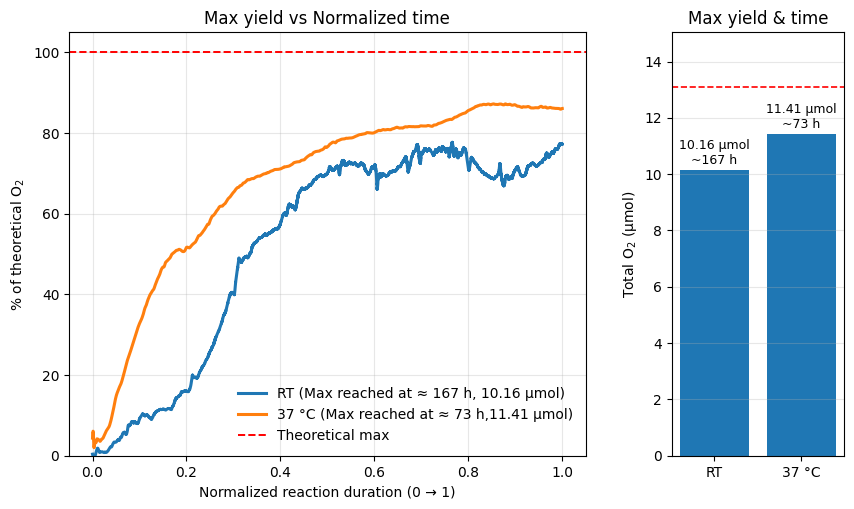

In [9]:
import numpy as np
import matplotlib.pyplot as plt
from matplotlib.gridspec import GridSpec
import pandas as pd

# --- file paths ---
main_RT_csv = r"C:\Users\chand\Documents\GitHub\Thesis\M2_2.18mM_pressure_o2_release.csv"         # 25 °C
henry_RT_csv = r"C:\Users\chand\Documents\GitHub\Thesis\CSV files outputs -RT\Vant hoff modelling\henry's constants.csv"

main_37_csv = r"C:\Users\chand\Documents\GitHub\Thesis\M2_2.18mM_37deg_pressure_o2_release.csv"   # 37 °C
henry_37_csv = r"C:\Users\chand\Documents\GitHub\Thesis\37deg at 4mL\henrys_constants_37deg.csv"

# --- column names (common) ---
time_col  = "Time (s)"
press_col = "DWT denoised pressure (kPa)"

# --- constants ---
R    = 0.082057            # L·atm·mol^-1·K^-1
Vsol = 0.006               # L
Vg   = 0.004               # L
# T_RT = 298.15              # K (25 °C)
# T_37 = 310.15              # K (37 °C)
n_theory = 13.08           # µmol (optional reference line)

def compute_ntotal_series(main_csv, kh_csv, label):
    """Return a tidy df with time_h and n_total (µmol) for a dataset."""
    df = pd.read_csv(main_csv)
    df.columns = [c.strip() for c in df.columns]
    df_kh = pd.read_csv(kh_csv)
    df_kh.columns = [c.strip() for c in df_kh.columns]

    time_h = pd.to_numeric(df[time_col], errors="coerce") 
    p_kPa  = pd.to_numeric(df[press_col], errors="coerce")
    p_atm  = p_kPa / 101.325

    kH_time = pd.to_numeric(df_kh["kH_mol_per_L_atm"], errors="coerce")
    T_K = pd.to_numeric(df_kh["Temperature_K"], errors="coerce")

    A_total = (Vg / (R * T_K)) + (kH_time * Vsol)
    n_total_umol = (p_atm * A_total) * 1e6

    return pd.DataFrame({
        "Elapsed Time (h)": time_h,
        "n_total (µmol)": n_total_umol,
        "label": label
    })

# --- compute both series ---
df_rt  = compute_ntotal_series(main_RT_csv, henry_RT_csv,  label="RT = 10.16 µmol")
df_37  = compute_ntotal_series(main_37_csv, henry_37_csv,  label="37 °C =  11.41 µmol")










# --- helpers ---
def finish_time(df, frac=0.99):
    y = df["n_total (µmol)"].to_numpy()
    t = df["Elapsed Time (h)"].to_numpy()
    y_max = np.nanmax(y)
    thresh = frac * y_max
    idx = np.where(y >= thresh)[0]
    return (t[idx[0]] if idx.size else t[-1]), y_max

# compute completion times (~99% of each max) and final yields
t_rt,  y_rt_max  = finish_time(df_rt,  frac=0.99)
t_37,  y_37_max  = finish_time(df_37,  frac=0.99)

# build normalized-time series (0..1) and percent-of-theoretical
def normalize(df, y_theory):
    t = df["Elapsed Time (h)"].to_numpy()
    y = df["n_total (µmol)"].to_numpy()
    t_norm = (t - t.min()) / (t.max() - t.min())  # 0..1 per series
    y_pct_theory = 100 * (y / y_theory)
    return t_norm, y_pct_theory

tN_rt,  yPct_rt  = normalize(df_rt,  n_theory)
tN_37,  yPct_37  = normalize(df_37,  n_theory)

# --- figure with 2 panels ---
plt.figure(figsize=(10, 5.5))
gs = GridSpec(1, 2, width_ratios=[3, 1], wspace=0.25)

# (A) Percent-of-theoretical vs normalized time
ax = plt.subplot(gs[0])
ax.plot(tN_rt,  yPct_rt,  lw=2.2, label=f"RT (Max reached at ≈ {t_rt:.0f} h, {y_rt_max:.2f} µmol)")
ax.plot(tN_37,  yPct_37, lw=2.2, label=f"37 °C (Max reached at ≈ {t_37:.0f} h,{y_37_max:.2f} µmol)")
ax.axhline(100, ls="--", lw=1.4, color="red", label="Theoretical max")
ax.set_xlabel("Normalized reaction duration (0 → 1)")
ax.set_ylabel("% of theoretical O$_2$")
ax.set_title("Max yield vs Normalized time")
ax.set_ylim(0, max(105, np.nanmax([yPct_rt.max(), yPct_37.max()]) * 1.05))
ax.grid(True, alpha=0.3)
ax.legend(loc="lower right", frameon=False)

# (B) Final yield + time-to-completion bars
ax2 = plt.subplot(gs[1])
bars = ax2.bar(
    ["RT", "37 °C"],
    [y_rt_max, y_37_max],
)
# annotate bars with time-to-99% and value
for rect, t_done, y_max in zip(bars, [t_rt, t_37], [y_rt_max, y_37_max]):
    ax2.text(rect.get_x() + rect.get_width()/2, rect.get_height()*1.01,
             f"{y_max:.2f} µmol\n~{t_done:.0f} h",
             ha="center", va="bottom", fontsize=9)
ax2.axhline(n_theory, ls="--", lw=1.2, color="red")
ax2.set_ylabel("Total O$_2$ (µmol)")
ax2.set_title("Max yield & time")
ax2.set_ylim(0, max(n_theory*1.15, y_37_max*1.2))
ax2.grid(True, axis="y", alpha=0.3)


plt.tight_layout()
plt.show()


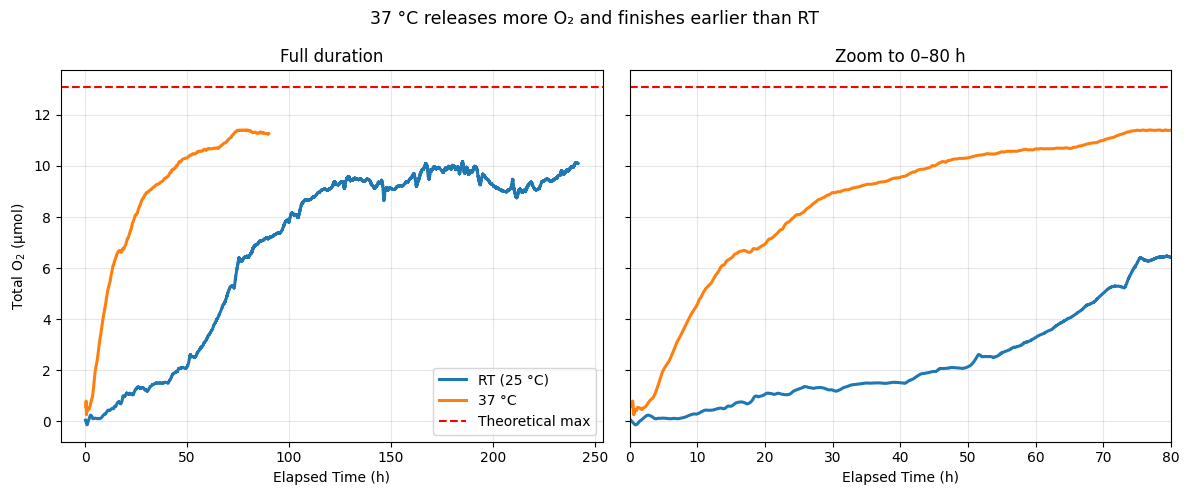

In [ ]:
fig, axes = plt.subplots(1, 2, figsize=(12,5), sharey=True)

# full duration
axes[0].plot(df_rt["Elapsed Time (h)"], df_rt["n_total (µmol)"], lw=2.2, label="RT (25 °C)")
axes[0].plot(df_37["Elapsed Time (h)"], df_37["n_total (µmol)"], lw=2.2, label="37 °C")
axes[0].axhline(n_theory, ls="--", color="red", label="Theoretical max")
axes[0].set_title("Full duration")
axes[0].set_xlabel("Elapsed Time (h)")
axes[0].set_ylabel("Total O$_2$ (µmol)")
axes[0].grid(True, alpha=0.3)
axes[0].legend()

# zoom to 0–80h
axes[1].plot(df_rt["Elapsed Time (h)"], df_rt["n_total (µmol)"], lw=2.2, label="RT (25 °C)")
axes[1].plot(df_37["Elapsed Time (h)"], df_37["n_total (µmol)"], lw=2.2, label="37 °C")
axes[1].axhline(n_theory, ls="--", color="red")
axes[1].set_xlim(0, 80)
axes[1].set_title("Zoom to 0–80 h")
axes[1].set_xlabel("Elapsed Time (h)")
axes[1].grid(True, alpha=0.3)

# plt.suptitle("37 °C releases more O₂ and finishes earlier than RT", fontsize=12.5)
plt.tight_layout()
plt.show()


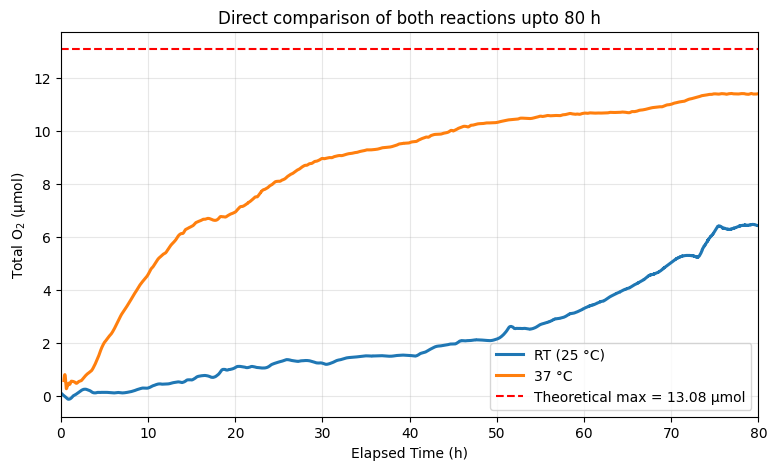

In [7]:
plt.figure(figsize=(9,5))
plt.plot(df_rt["Elapsed Time (h)"], df_rt["n_total (µmol)"], lw=2.2, label="RT (25 °C)")
plt.plot(df_37["Elapsed Time (h)"], df_37["n_total (µmol)"], lw=2.2, label="37 °C")

plt.axhline(n_theory, ls="--", color="red", label=f"Theoretical max = {n_theory} µmol")

plt.xlim(0, 80)   # zoom-in to 0–80 h
plt.xlabel("Elapsed Time (h)")
plt.ylabel("Total O$_2$ (µmol)")
plt.title("Direct comparison of both reactions upto 80 h")
plt.legend()
plt.grid(True, alpha=0.3)
plt.show()


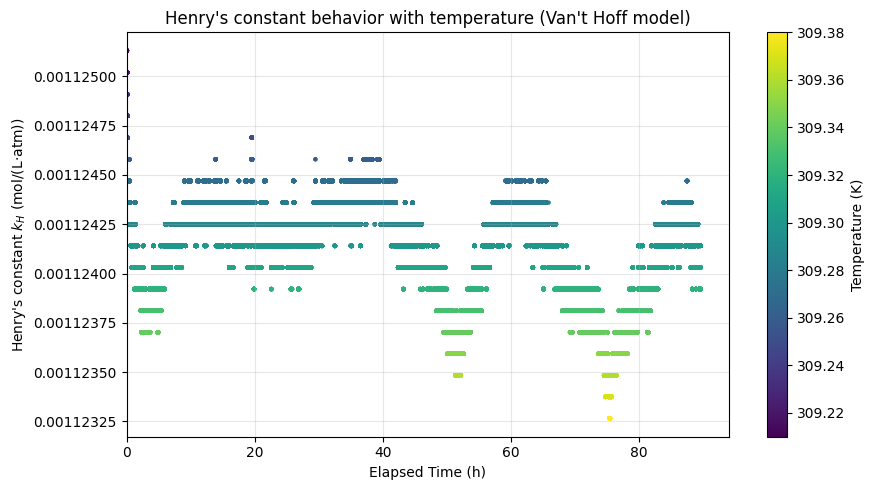

In [11]:

# Behaviour profile of KH with respect to time and temperature (Room temperature data)


import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
from pathlib import Path

main_csv_path = r"C:\Users\chand\Documents\GitHub\Thesis\37deg at 4mL\ntotal_output_37.csv"
side_csv_path = r"C:\Users\chand\Documents\GitHub\Thesis\37deg at 4mL\henrys_constants_37deg.csv"
henry_values  = "kH (mol/L/atm)"
ntot          = "n_total(µmol)"
time_col      = "Elapsed Time (h)"
T_K           = "Temperature_K"

# Load data
df_main = pd.read_csv(main_csv_path)
df_main.columns = [c.strip() for c in df_main.columns]

df_side = pd.read_csv(side_csv_path)
df_side.columns = [c.strip() for c in df_side.columns]

# Parse columns
t_h   = pd.to_numeric(df_main[time_col], errors="coerce")
n_tot = pd.to_numeric(df_main[ntot], errors="coerce")
k_h   = pd.to_numeric(df_main[henry_values], errors="coerce")
t_k   = pd.to_numeric(df_side[T_K], errors="coerce")

# Ensure same length
n = min(len(n_tot), len(t_h), len(k_h), len(t_k))
t_h, n_tot, k_h, t_k = [s.iloc[:n].reset_index(drop=True) for s in (t_h, n_tot, k_h, t_k)]
t_h = t_h - t_h.iloc[0]  # start at 0 h

# Plot kH over time, color-coded by temperature
plt.figure(figsize=(9, 5))
sc = plt.scatter(t_h, k_h, c=t_k, cmap='viridis', s=10, edgecolors='none')
cbar = plt.colorbar(sc)
cbar.set_label("Temperature (K)")

plt.xlabel("Elapsed Time (h)")
plt.ylabel("Henry's constant $k_H$ (mol/(L·atm))")
plt.title("Henry's constant behavior with temperature (Van't Hoff model)")
plt.grid(True, alpha=0.3)
plt.xlim(left=0)
plt.tight_layout()
plt.show()



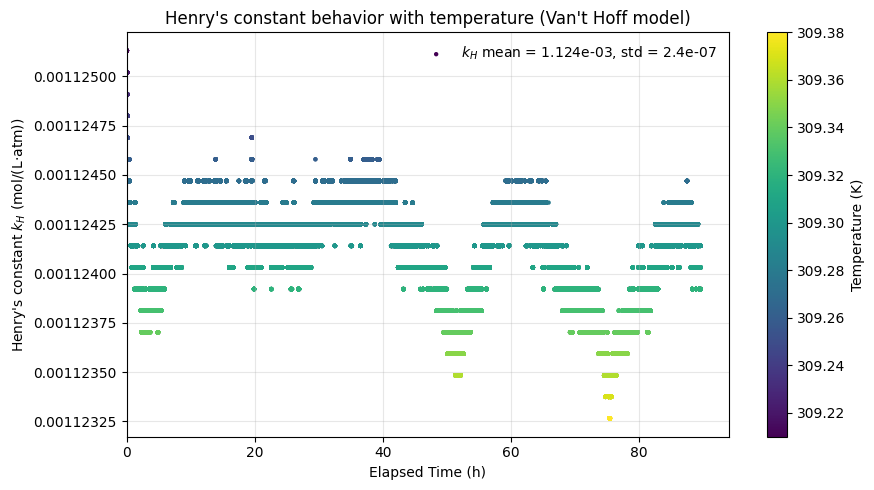

In [12]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
from pathlib import Path

main_csv_path = r"C:\Users\chand\Documents\GitHub\Thesis\37deg at 4mL\ntotal_output_37.csv"
side_csv_path = r"C:\Users\chand\Documents\GitHub\Thesis\37deg at 4mL\henrys_constants_37deg.csv"
henry_values  = "kH (mol/L/atm)"
ntot          = "n_total(µmol)"
time_col      = "Elapsed Time (h)"
T_K           = "Temperature_K"

# Load data
df_main = pd.read_csv(main_csv_path)
df_main.columns = [c.strip() for c in df_main.columns]

df_side = pd.read_csv(side_csv_path)
df_side.columns = [c.strip() for c in df_side.columns]

# Parse columns
t_h   = pd.to_numeric(df_main[time_col], errors="coerce")
n_tot = pd.to_numeric(df_main[ntot], errors="coerce")
k_h   = pd.to_numeric(df_main[henry_values], errors="coerce")
t_k   = pd.to_numeric(df_side[T_K], errors="coerce")

# Ensure same length
n = min(len(n_tot), len(t_h), len(k_h), len(t_k))
t_h, n_tot, k_h, t_k = [s.iloc[:n].reset_index(drop=True) for s in (t_h, n_tot, k_h, t_k)]
t_h = t_h - t_h.iloc[0]  # start at 0 h

# --- stats for legend ---
k_mean = np.nanmean(k_h)
k_std  = np.nanstd(k_h)
label_stats = f"$k_H$ mean = {k_mean:.3e}, std = {k_std:.1e}"

# Plot kH over time, color-coded by temperature
plt.figure(figsize=(9, 5))
sc = plt.scatter(t_h, k_h, c=t_k, cmap='viridis', s=10, edgecolors='none', label=label_stats)
cbar = plt.colorbar(sc)
cbar.set_label("Temperature (K)")

plt.xlabel("Elapsed Time (h)")
plt.ylabel("Henry's constant $k_H$ (mol/(L·atm))")
plt.title("Henry's constant behavior with temperature (Van't Hoff model)")
plt.grid(True, alpha=0.3)
plt.xlim(left=0)
plt.legend(loc="best", frameon=False)
plt.tight_layout()
plt.show()


# EDA with first order kinetics



## To plot the C_EPO vs C_ANT graph to see decay and formation 

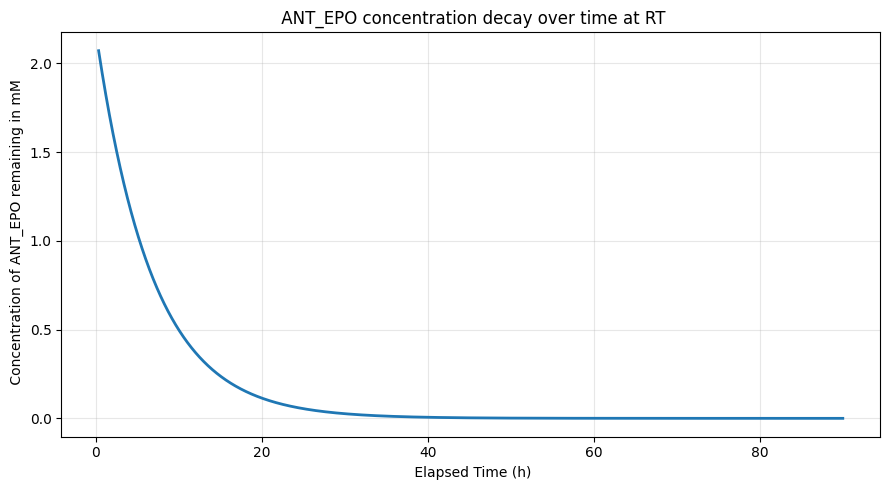

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

# Aim is to find N(t) = N0 * 0.5^(t/t_half)

n_0 = 2.18  # initial ANT- EPO concentration in mM
t_halflife = 4.7 #hours at 37



csv_path = r"C:\Users\chand\Documents\GitHub\Thesis\M2_2.18mM_37deg_pressure_o2_release.csv"
df = pd.read_csv(csv_path)
df.columns = [c.strip() for c in df.columns]

df["Elapsed time"] = pd.to_numeric(df["Time (s)"])   #The OG column Time (S) is actually in hours, its named wrongly.

df["N (t)"] = n_0 * 0.5**(df["Elapsed time"] / t_halflife)  #N(t) is also in mM

df["N (t) in %"] = (df["N (t)"] / n_0) * 100  #N(t) in percentage

df["C_ANT_mM"] = n_0 - df["N (t)"] 


out_dataframe = df[["Elapsed time", "N (t)", "N (t) in %", "C_ANT_mM"]]
plt.figure(figsize=(9, 5))
plt.plot(out_dataframe["Elapsed time"], out_dataframe["N (t)"], linewidth =2)
plt.xlabel(" Elapsed Time (h)")
plt.ylabel(" Concentration of ANT_EPO remaining in mM")
plt.title (" ANT_EPO concentration decay over time at RT")

plt.grid(True, alpha=0.3)
plt.tight_layout()

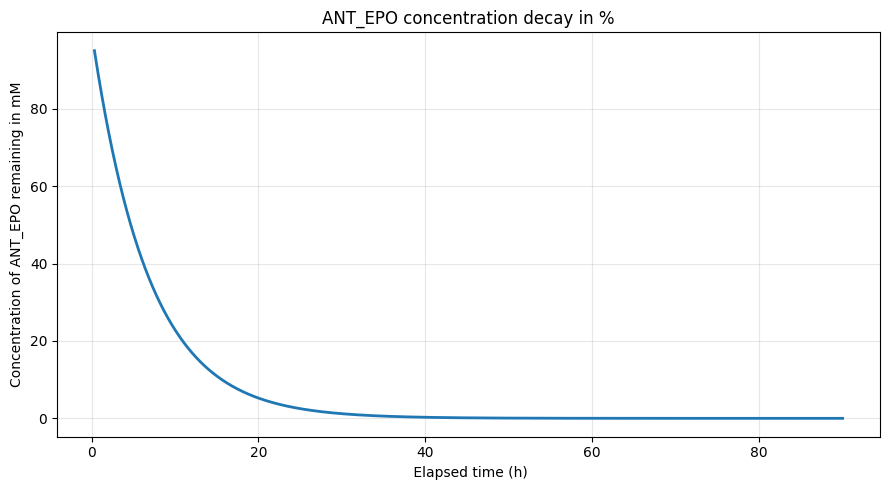

In [2]:
plt.figure(figsize =(9,5))
plt.plot(out_dataframe["Elapsed time"], out_dataframe["N (t) in %"], linewidth =2)
plt.xlabel(" Elapsed time (h)")
plt.ylabel("Concentration of ANT_EPO remaining in mM")
plt.title("ANT_EPO concentration decay in %")
plt.grid(True, alpha=0.3)
plt.tight_layout()
plt.show()

In [7]:
import pandas as pd
import numpy as np

# Parameters
n_0 = 2.18        # initial ANT-EPO concentration in mM
t_halflife = 4.7 # hours at 37

# Table 9 timestamps (in hours)
timestamps_h = [0, 0.46, 1.005, 2.238, 3.405, 5.388, 6.172, 7.222, 
                22.85, 47.27, 71.38, 100]

# Convert into DataFrame
df_out = pd.DataFrame({"Elapsed_h": timestamps_h})
# Compute N(t), % remaining, and ANT formed
df_out["C_EPO_mM"] = n_0 * 0.5**(df_out["Elapsed_h"] / t_halflife)  # remaining ANT-EPO
df_out["EPO_remaining_%"] = (df_out["C_EPO_mM"] / n_0) * 100        # %
df_out["C_ANT_mM"] = n_0 - df_out["C_EPO_mM"]                       # formed anthracene


# Save or display
print(df_out.head())
df_out.to_csv("epo_table9_style.csv", index=False)


   Elapsed_h  C_EPO_mM  EPO_remaining_%  C_ANT_mM
0      0.000  2.180000       100.000000  0.000000
1      0.460  2.037014        93.441003  0.142986
2      1.005  1.879695        86.224527  0.300305
3      2.238  1.567166        71.888345  0.612834
4      3.405  1.319380        60.522015  0.860620


In [8]:
from tabulate import tabulate

# Round values for readability
df_out_rounded = df_out.round({

    "C_EPO_mM": 3,
    "EPO_remaining_%": 2,
    "C_ANT_mM": 3
})

# Create a clean table string
table_str = tabulate(
    df_out_rounded,
    headers=[ "C_EPO (mM)", "EPO Remaining (%)", "C_ANT (mM)"],
    tablefmt="github"
)

print(table_str)


|    |         |   C_EPO (mM) |   EPO Remaining (%) |   C_ANT (mM) |
|----|---------|--------------|---------------------|--------------|
|  0 |   0     |        2.18  |              100    |        0     |
|  1 |   0.46  |        2.037 |               93.44 |        0.143 |
|  2 |   1.005 |        1.88  |               86.22 |        0.3   |
|  3 |   2.238 |        1.567 |               71.89 |        0.613 |
|  4 |   3.405 |        1.319 |               60.52 |        0.861 |
|  5 |   5.388 |        0.985 |               45.18 |        1.195 |
|  6 |   6.172 |        0.877 |               40.24 |        1.303 |
|  7 |   7.222 |        0.751 |               34.47 |        1.429 |
|  8 |  22.85  |        0.075 |                3.44 |        2.105 |
|  9 |  47.27  |        0.002 |                0.09 |        2.178 |
| 10 |  71.38  |        0     |                0    |        2.18  |
| 11 | 100     |        0     |                0    |        2.18  |


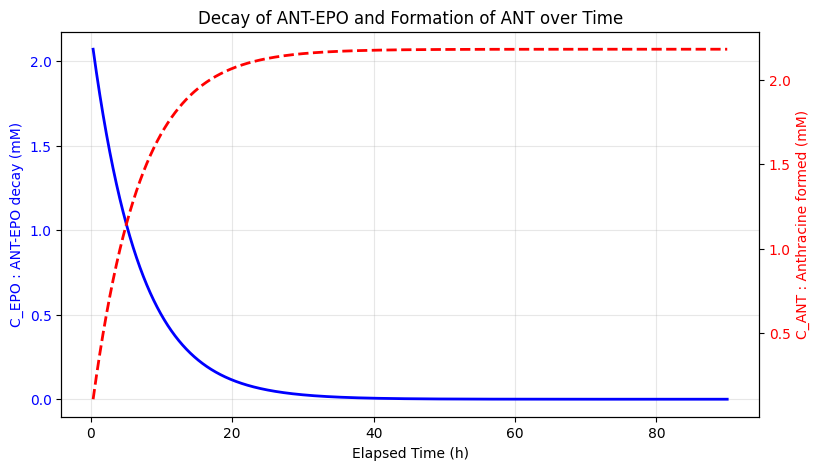

In [9]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

# Parameters
n_0 = 2.18        # initial ANT-EPO concentration (mM)
t_half = 4.7    # hours at 37 °C
fig, ax1 = plt.subplots(figsize=(9,5))

# Left axis: C_EPO
ax1.plot(out_dataframe["Elapsed time"], out_dataframe["N (t)"], 'b-', linewidth=2, label="C_EPO (mM)")
ax1.set_xlabel("Elapsed Time (h)")
ax1.set_ylabel("C_EPO : ANT-EPO decay (mM)", color='b')
ax1.tick_params(axis='y', labelcolor='b')

# Right axis: C_ANT
ax2 = ax1.twinx()
ax2.plot(out_dataframe["Elapsed time"], out_dataframe["C_ANT_mM"], 'r--', linewidth=2, label="C_ANT (mM)")
ax2.set_ylabel("C_ANT : Anthracine formed (mM)", color='r')
ax2.tick_params(axis='y', labelcolor='r')

plt.title("Decay of ANT-EPO and Formation of ANT over Time")
ax1.grid(alpha=0.3)

plt.show()

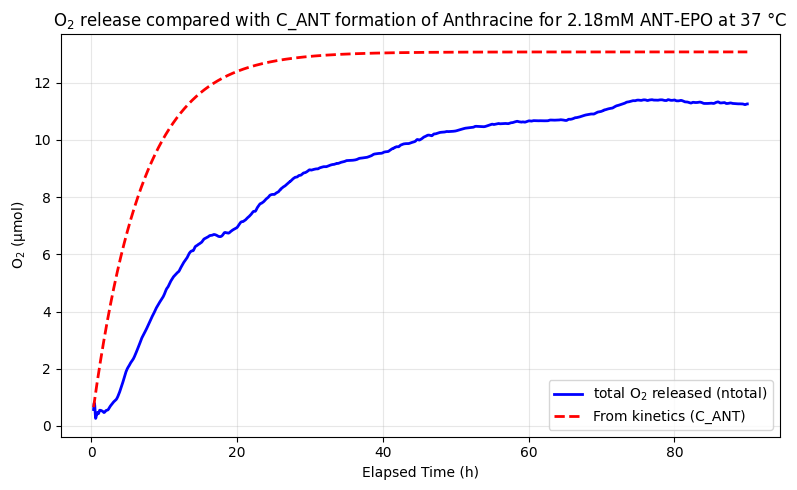

In [12]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

# ---------- inputs ----------
main_csv   = r"C:\Users\chand\Documents\GitHub\Thesis\37deg at 4mL\O2_37released_multi_volumes.csv"
kh_csv =r"C:\Users\chand\Documents\GitHub\Thesis\37deg at 4mL\henrys_constants_37deg.csv"
time_col   = "Time (s)"  
press_col  = "DWT denoised pressure (kPa)"                                  

# ---------- constants ----------
R = 0.082057            # L·atm·mol^-1·K^-1
Vsol = 0.006            # L
Vg   = 0.004            # L
n_theory = 13.08       # µmol (theoretical maximum O2)

# ---------- load ----------
df = pd.read_csv(main_csv)
df.columns = [c.strip() for c in df.columns]
df_kh = pd.read_csv(kh_csv)
df_kh.columns = [c.strip() for c in df_kh.columns]
T_time  = pd.to_numeric(df_kh["Temperature_K"],    errors="coerce")
time_h = pd.to_numeric(df[time_col], errors="coerce")
p_kpa  = pd.to_numeric(df[press_col], errors="coerce")
kH_time = df_kh["kH_mol_per_L_atm"]
p_atm = p_kpa / 101.325    # convert kPa to atm

# ---------- calculate n_total ----------
def calculate_n_total(p_atm, Vg, Vsol, R, T, KH):
    ntot = p_atm * ((Vg / (R*T)) + (KH * Vsol))
    return ntot * 1e6  # µmol

ntot_umol = calculate_n_total(p_atm, Vg, Vsol, R, T_time, kH_time)


df_out = pd.DataFrame({
    "Elapsed time" : time_h,
    "ntotal (µmol)": ntot_umol
})

# Convert directly to %
out_dataframe["C_ANT_%"] = (out_dataframe["C_ANT_mM"] / n_0) * 100
df_out["ntotal_%"] = (df_out["ntotal (µmol)"] / n_theory) * 100
# ---------- kinetic model overlay ----------
# Parameters for ANT-EPO kinetics
n0_mM = 2.18       # initial ANT-EPO concentration (mM)
t_half = 4.7     # hours at 37 °C

# Use same time base as pressure data
elapsed_h = df_out["Elapsed time"]

# Kinetic model: concentration of ANT formed (mM)
C_ANT_mM = n0_mM * (1 - 0.5**(elapsed_h / t_half))

# Convert C_ANT to µmol (multiply by Vsol in L and by 1000)
C_ANT_umol = C_ANT_mM * Vsol * 1000

# ---------- plot ----------
plt.figure(figsize=(8,5))
plt.plot(elapsed_h, df_out["ntotal (µmol)"], 'b-', linewidth=2, label="total O$_2$ released (ntotal)")
plt.plot(elapsed_h, C_ANT_umol, 'r--', linewidth=2, label="From kinetics (C_ANT)")

plt.xlabel("Elapsed Time (h)")
plt.ylabel("O$_2$ (µmol)")
plt.title("O$_2$ release compared with C_ANT formation of Anthracine for 2.18mM ANT-EPO at 37 °C")
plt.legend()
plt.grid(alpha=0.3)
plt.tight_layout()
plt.show()

# Preprocessing to remove the initial deflection

C:\Users\chand\AppData\Local\Temp\ipykernel_1228\970249949.py:37: FutureWarning: Series.fillna with 'method' is deprecated and will raise in a future version. Use obj.ffill() or obj.bfill() instead.
  slope_sm = pd.Series(slope).rolling(window=max(3, 2*(smooth_n//2)+1), center=True).median().fillna(method="bfill").fillna(method="ffill").values


Detected stable start at t ≈ 1.024 h (index 2437)
Samples/hour ≈ 3600.0, persist_n = 480, smooth_n = 180


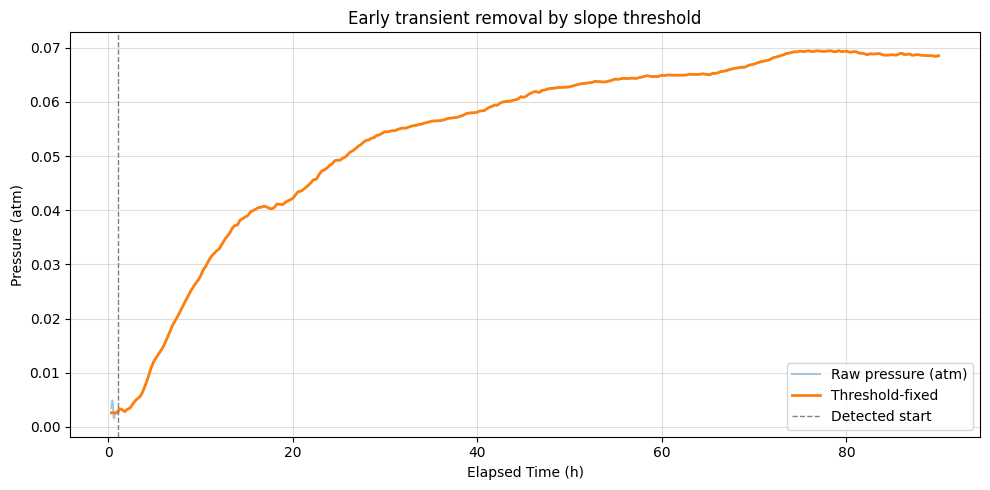

In [18]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

# --- params you can tune ---
SEARCH_HOURS = 1.0          # only look for stabilization in the first 1 h
SLOPE_SMOOTH_MIN = 3        # smooth slope over ~3 minutes (approx)
PERSIST_MIN = 8             # require slope above threshold for 8 minutes consecutively
SLOPE_THRESH = 0.0015       # atm per hour; raise/lower if too sensitive
FIX_MODE = "flatten"        # "flatten" or "trim"

# --- load ---
main_csv = r"C:\Users\chand\Documents\GitHub\Thesis\M2_2.18mM_37deg_pressure_o2_release.csv"
df = pd.read_csv(main_csv)
df.columns = [c.strip() for c in df.columns]

t = df["Time (s)"].values           # actually hours
p = (df["DWT denoised pressure (kPa)"] / 101.325).values  # atm

# --- estimate samples per hour (assumes near-uniform sampling) ---
span_h = t[-1] - t[0]
sph = len(t) / span_h if span_h > 0 else 1.0  # samples/hour

# window sizes in samples (ensure >=1 and odd when used for median-like ops)
def to_samples(minutes):
    return max(1, int(round(sph * (minutes/60.0))))

smooth_n = max(1, to_samples(SLOPE_SMOOTH_MIN))
persist_n = max(1, to_samples(PERSIST_MIN))

# --- compute slope dP/dt (atm/hour) and smooth it with a rolling median ---
dt = np.gradient(t)
dp = np.gradient(p)
slope = np.divide(dp, dt, out=np.zeros_like(dp), where=dt != 0)

# simple rolling median smoothing for robustness
slope_sm = pd.Series(slope).rolling(window=max(3, 2*(smooth_n//2)+1), center=True).median().fillna(method="bfill").fillna(method="ffill").values

# --- search for first stable start in the first SEARCH_HOURS ---
search_mask = t <= (t[0] + SEARCH_HOURS)
idxs = np.where(search_mask)[0]
start_idx = idxs[0]

stable_idx = None
# look for a run of length 'persist_n' with slope above threshold
for i in range(start_idx, idxs[-1] - persist_n + 1):
    if np.all(slope_sm[i:i+persist_n] > SLOPE_THRESH):
        stable_idx = i
        break

# fallback: if not found, use the last point in search window
if stable_idx is None:
    stable_idx = idxs[-1]

# --- fix early data ---
p_fixed = p.copy()
if FIX_MODE == "flatten":
    # make the early part equal to the first stable value
    p_fixed[:stable_idx] = p_fixed[stable_idx]
elif FIX_MODE == "trim":
    # drop the early transient entirely
    t = t[stable_idx:]
    p = p[stable_idx:]
    p_fixed = p.copy()
 

# --- params to add ---
BLEND_MIN = 5  # minutes to feather the transition

# ... after you compute `stable_idx` and before plotting:

p_fixed = p.copy()
p_flat = p[stable_idx]             # value we flatten to before start
p_fixed[:stable_idx] = p_flat      # keep the early part flat

# Feather the last few minutes before the start
blend_n = max(1, to_samples(BLEND_MIN))
lo = max(0, stable_idx - blend_n)
w = np.linspace(0.0, 1.0, stable_idx - lo, endpoint=False)   # 0→1 ramp
p_fixed[lo:stable_idx] = (1 - w) * p_flat + w * p[lo:stable_idx]   
    
    
    
    
    

print(f"Detected stable start at t ≈ {t[stable_idx]:.3f} h (index {stable_idx})")
print(f"Samples/hour ≈ {sph:.1f}, persist_n = {persist_n}, smooth_n = {smooth_n}")

# --- plot ---
plt.figure(figsize=(10,5))
plt.plot(t, p, label="Raw pressure (atm)", alpha=0.4)
plt.plot(t, p_fixed, label="Threshold-fixed", linewidth=2)
plt.axvline(t[stable_idx], color="gray", ls="--", lw=1, label="Detected start")
plt.xlabel("Elapsed Time (h)")
plt.ylabel("Pressure (atm)")
plt.title("Early transient removal by slope threshold")
plt.legend()
plt.grid(True, alpha=0.4)
plt.tight_layout()
plt.show()


# Next steps
1. Store the above pressure results in a dataframe, copy the OG dataframe into this without the pressure. perform EDA once again with that smoothed version
2. 2.1mM - pressure 37 also needs signal smoothing before converting raw data into OG file to use for preprocessing
3. 2.1mM - pressure RT needs a merged raw meas file, create it from the given script
4. Optical measurement needs a different script to preprocess the raw data. perform that. 

